In [1]:
# Core data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tabular forecasting models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Scaling for the LSTM sequence model
from sklearn.preprocessing import MinMaxScaler

# Deep learning model for sequence forecasting
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input
from keras.callbacks import EarlyStopping

# Interactive controls for the demo notebook
from ipywidgets import interact, IntSlider, Dropdown

In [2]:
# Load feature-based datasets for the tabular models
train_features = pd.read_csv("../data/processed/train_features.csv")
val_features = pd.read_csv("../data/processed/val_features.csv")
test_features = pd.read_csv("../data/processed/test_features.csv")

# Load hourly datasets for the LSTM sequence model
train_hourly = pd.read_csv("../data/processed/train_hourly.csv")
val_hourly = pd.read_csv("../data/processed/val_hourly.csv")
test_hourly = pd.read_csv("../data/processed/test_hourly.csv")

# Convert the hour column to datetime so it can be used in plots and alignment
for df in [train_features, val_features, test_features, train_hourly, val_hourly, test_hourly]:
    df["hour"] = pd.to_datetime(df["hour"], utc=True, errors="coerce")

print("Train features shape:", train_features.shape)
print("Validation features shape:", val_features.shape)
print("Test features shape:", test_features.shape)

print("Train hourly shape:", train_hourly.shape)
print("Validation hourly shape:", val_hourly.shape)
print("Test hourly shape:", test_hourly.shape)

Train features shape: (20997, 12)
Validation features shape: (1296, 12)
Test features shape: (890, 12)
Train hourly shape: (21165, 7)
Validation hourly shape: (1464, 7)
Test hourly shape: (1058, 7)


In [3]:
# Define the predictor columns used by the tabular models
feature_cols = [
    "hour_of_day",
    "day_of_week",
    "month",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
]

# Define the forecasting target
target_col = "session_count"

# Split each dataset into predictors and target
X_train = train_features[feature_cols]
y_train = train_features[target_col]

X_val = val_features[feature_cols]
y_val = val_features[target_col]

X_test = test_features[feature_cols]
y_test = test_features[target_col]

In [4]:
# Train the tabular models used in the forecasting comparison
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

lasso_model = Lasso(alpha=0.001, max_iter=10000)
lasso_model.fit(X_train, y_train)

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1,
)
random_forest_model.fit(X_train, y_train)

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
)
gradient_boosting_model.fit(X_train, y_train)

print("Tabular models trained.")

Tabular models trained.


In [5]:
def create_sequences(series: np.ndarray, sequence_length: int):
    """
    Convert a 1D series into supervised sequences for the LSTM.

    Each input uses the previous sequence_length hours,
    and the target is the next-hour demand value.
    """
    X, y = [], []

    for i in range(sequence_length, len(series)):
        X.append(series[i - sequence_length:i])
        y.append(series[i])

    return np.array(X), np.array(y)

In [6]:
# Use the better LSTM sequence length from the earlier experiments
sequence_length = 24
lstm_units = 32
epochs = 30
batch_size = 32

# Extract the target series for sequence forecasting
train_series = train_hourly[target_col].values.reshape(-1, 1)
val_series = val_hourly[target_col].values.reshape(-1, 1)
test_series = test_hourly[target_col].values.reshape(-1, 1)

# Scale the target values to make LSTM training more stable
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_series)
val_scaled = scaler.transform(val_series)
test_scaled = scaler.transform(test_series)

# Build supervised sequence datasets
X_train_seq, y_train_seq = create_sequences(train_scaled, sequence_length)
X_val_seq, y_val_seq = create_sequences(val_scaled, sequence_length)
X_test_seq, y_test_seq = create_sequences(test_scaled, sequence_length)

# Reshape into the format expected by Keras LSTM: [samples, timesteps, features]
X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], X_train_seq.shape[1], 1))
X_val_seq = X_val_seq.reshape((X_val_seq.shape[0], X_val_seq.shape[1], 1))
X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], X_test_seq.shape[1], 1))

print("LSTM training shape:", X_train_seq.shape)
print("LSTM validation shape:", X_val_seq.shape)
print("LSTM test shape:", X_test_seq.shape)

LSTM training shape: (21141, 24, 1)
LSTM validation shape: (1440, 24, 1)
LSTM test shape: (1034, 24, 1)


In [7]:
# Build and train the LSTM model
lstm_model = Sequential([
    # Input shape is [sequence_length, 1 feature]
    Input(shape=(sequence_length, 1)),

    # One LSTM layer to learn temporal patterns
    LSTM(lstm_units),

    # Final dense layer outputs one predicted session_count value
    Dense(1)
])

# Use Adam optimizer and mean squared error loss
lstm_model.compile(optimizer="adam", loss="mse")

# Stop early if validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

# Train the model on the sequence data
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    callbacks=[early_stopping],
)

print("LSTM model trained.")

Epoch 1/30
661/661 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0058 - val_loss: 0.0024
Epoch 2/30
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0047 - val_loss: 0.0024
Epoch 3/30
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0046 - val_loss: 0.0024
Epoch 4/30
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0044 - val_loss: 0.0024
Epoch 5/30
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0044 - val_loss: 0.0026
Epoch 6/30
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0043 - val_loss: 0.0024
Epoch 7/30
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0042 - val_loss: 0.0026
Epoch 8/30
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0041 - val_loss: 0.0027
Epoch 9/30
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0041 - val_loss: 0.0024
Epoch 10/30
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0040 - val_loss: 0.0025
Epoch 11/30
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0040 - val_loss: 0.0027
Epoch 12/30
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [8]:
# Build one demo table using the test feature dataset
demo_df = test_features[["hour", "session_count"]].copy()
demo_df = demo_df.rename(columns={"session_count": "actual"})

# Add predictions from each tabular model
demo_df["Linear Regression"] = linear_model.predict(X_test)
demo_df["Ridge Regression"] = ridge_model.predict(X_test)
demo_df["Lasso Regression"] = lasso_model.predict(X_test)
demo_df["Random Forest"] = random_forest_model.predict(X_test)
demo_df["Gradient Boosting"] = gradient_boosting_model.predict(X_test)

# Generate LSTM predictions on the test sequence data
lstm_pred_scaled = lstm_model.predict(X_test_seq, verbose=0)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()

# Align LSTM predictions with the correct test-set timestamps
lstm_hours = test_hourly["hour"].iloc[sequence_length:].reset_index(drop=True)
lstm_df = pd.DataFrame({
    "hour": lstm_hours,
    "LSTM": lstm_pred,
})

# Merge the LSTM predictions into the demo table by timestamp
demo_df = demo_df.merge(lstm_df, on="hour", how="left")

print("Demo table shape:", demo_df.shape)
demo_df.head()

Demo table shape: (890, 8)


,hour,actual,Linear Regression,Ridge Regression,Lasso Regression,Random Forest,Gradient Boosting,LSTM
0,2021-08-08 00:00:00+00:00,1,0.783846,0.783842,0.787007,0.411838,0.501454,0.670114
1,2021-08-08 01:00:00+00:00,0,0.787898,0.787897,0.791250,0.421895,0.578256,0.716626
2,2021-08-08 02:00:00+00:00,2,0.619192,0.619190,0.622617,0.412831,0.549600,0.338592
3,2021-08-08 03:00:00+00:00,0,0.697139,0.697137,0.700214,0.370522,0.487335,0.888586
4,2021-08-08 04:00:00+00:00,1,0.359031,0.359033,0.362604,0.362117,0.501564,0.386369


In [9]:
def compute_metrics(y_true, y_pred):
    """
    Compute MAE, RMSE, and R² for one model.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


# List of models included in the demo comparison
model_names = [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression",
    "Random Forest",
    "Gradient Boosting",
    "LSTM",
]

# Build one summary table of test metrics
metrics_rows = []

for model_name in model_names:
    # Drop rows with missing values so the comparison stays aligned
    valid_df = demo_df.dropna(subset=[model_name]).copy()

    mae, rmse, r2 = compute_metrics(valid_df["actual"], valid_df[model_name])

    metrics_rows.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values("RMSE")
metrics_df

,Model,MAE,RMSE,R2
4,Gradient Boosting,0.666628,1.038134,0.373680
1,Ridge Regression,0.716829,1.094411,0.303935
0,Linear Regression,0.716830,1.094412,0.303933
2,Lasso Regression,0.716390,1.094471,0.303859
3,Random Forest,0.690856,1.154844,0.224940
5,LSTM,0.730831,1.158452,0.220089


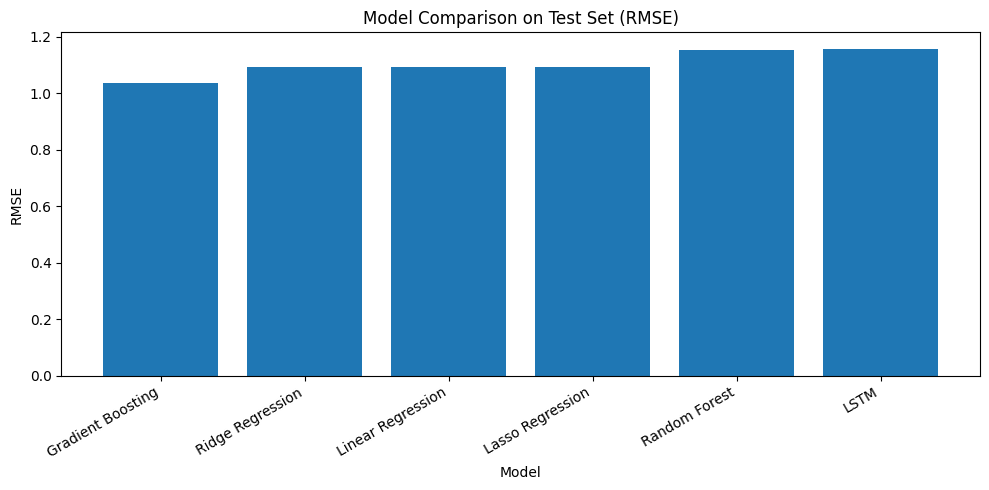

In [10]:
# Plot a simple comparison of test RMSE across models
plt.figure(figsize=(10, 5))
plt.bar(metrics_df["Model"], metrics_df["RMSE"])
plt.title("Model Comparison on Test Set (RMSE)")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [11]:
def demo_forecast(selected_time=None, window=48):
    """
    Interactive forecasting demo using a selected timestamp from the test set.

    selected_time:
        Choose one timestamp from the aligned test-set table

    window:
        Number of points to show in the local comparison plot
    """
    # Convert the chosen timestamp string back to datetime
    selected_time = pd.to_datetime(selected_time, utc=True)

    # Find the row that matches the selected timestamp
    matched_rows = demo_df[demo_df["hour"] == selected_time]

    if matched_rows.empty:
        print("Selected timestamp not found in demo table.")
        return

    row = matched_rows.iloc[0]
    index = matched_rows.index[0]

    print("Selected timestamp:", row["hour"])
    print("Actual session_count:", round(row["actual"], 4))
    print()

    # Build a comparison table of predictions for that selected timestamp
    result_table = pd.DataFrame({
        "Model": model_names,
        "Prediction": [
            row["Linear Regression"],
            row["Ridge Regression"],
            row["Lasso Regression"],
            row["Random Forest"],
            row["Gradient Boosting"],
            row["LSTM"],
        ]
    })

    # Compute the absolute error for each model
    result_table["Absolute Error"] = (result_table["Prediction"] - row["actual"]).abs()

    # Show the most accurate models first
    display(result_table.sort_values("Absolute Error"))

    # Build a local plotting window around the selected timestamp
    half_window = window // 2
    start_idx = max(0, index - half_window)
    end_idx = min(len(demo_df), index + half_window)

    plot_df = demo_df.iloc[start_idx:end_idx].copy()

    # Plot the local behavior of the main models around that timestamp
    plt.figure(figsize=(12, 6))
    plt.plot(plot_df["hour"], plot_df["actual"], label="Actual", linewidth=2)
    plt.plot(plot_df["hour"], plot_df["Linear Regression"], label="Linear Regression")
    plt.plot(plot_df["hour"], plot_df["Random Forest"], label="Random Forest")
    plt.plot(plot_df["hour"], plot_df["Gradient Boosting"], label="Gradient Boosting")
    plt.plot(plot_df["hour"], plot_df["LSTM"], label="LSTM")

    # Mark the selected timestamp
    plt.axvline(row["hour"], linestyle="--")

    plt.title("Forecast Demo Around Selected Timestamp")
    plt.xlabel("Time")
    plt.ylabel("Session Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [12]:
# Build a dropdown list of timestamps from the demo table
time_options = [str(t) for t in demo_df["hour"]]

# Interactive controls for the timestamp-based demo
interact(
    demo_forecast,
    selected_time=Dropdown(
        options=time_options,
        value=time_options[0],
        description="Timestamp"
    ),
    window=IntSlider(
        value=48,
        min=24,
        max=168,
        step=24,
        description="Window"
    ),
);

interactive(children=(Dropdown(description='Timestamp', options=('2021-08-08 00:00:00+00:00', '2021-08-08 01:0…